In [1]:
import trimesh
#import pyrender
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
import cv2
import glob
import sys

sys.path.append("../")

from oxels.obj_3d import render, get_pose, sample_random_on_mesh, get_visible_matches

### Get .obj filenames

In [2]:
model_files = glob.glob("/home/leonidp/pCloudDrive/NSF_CAREER/*/*/models/model_normalized.obj")

# Multi-view matching illustrated

### Render two views

In [3]:
### load model (trimesh automatically finds and loads textures ect.)

scene = trimesh.load(model_files[1], process=True)
scene = scene.scene() if isinstance(scene, trimesh.Trimesh) else scene

In [4]:
### chose reloution and focal length

resolution = W, H = (384, 256)
f1 = 500
f2 = 400

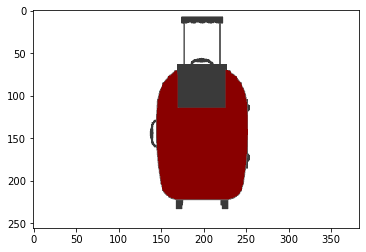

In [5]:
### make one view

d = np.array([0,0,2])
pose1 = get_pose(np.eye(3), d)

#NOTE: visible=True mkae s winwod pop up, but visible=False doens't wotk on some machines
I1 = render(scene, pose1, resolution, f1, visible=True)
plt.imshow(I1)

In [6]:
### Sample a "small" rotation marix
M = Rotation.from_euler("zxy", np.random.normal(0,30,3), degrees=True).as_matrix()

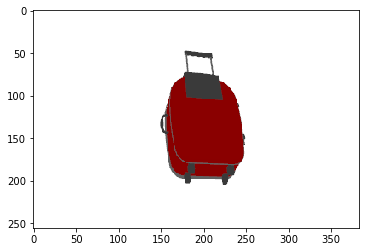

In [7]:
### make another view

pose2 = get_pose(M, M.dot(d))
I2 = render(scene, pose2, resolution, f2, visible=True)
plt.imshow(I2)

### Match pixels between views

In [8]:
### translate scene to mesh

mesh = trimesh.util.concatenate(scene.dump())

(179, 3) (179, 2)


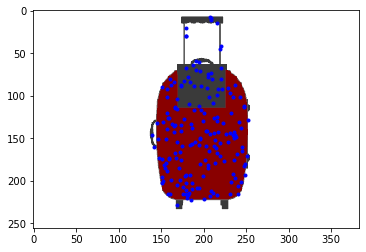

In [15]:
### sample random points on the mesh that are visibile in the first view

xyz, uv1 = sample_random_on_mesh(mesh, 2**10, pose1, f1, resolution)
print(xyz.shape, uv1.shape)
plt.imshow(I1)
plt.scatter(uv1[:,0], H-uv1[:,1], marker=".", color="b")

In [16]:
### filter points that are slao visible in the second view

match_mask, uv2 = get_visible_matches(mesh, xyz, pose2, f2, resolution)
uv1 = uv1[match_mask]

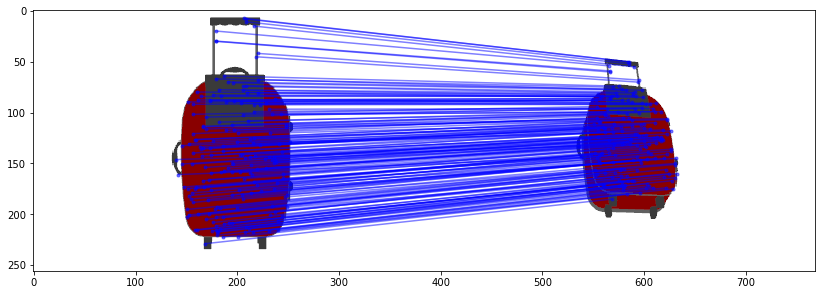

In [17]:
### plot matches

plt.figure(figsize=(14,7))
plt.imshow(np.concatenate([I1, I2], axis=1))
for i in range(len(uv1)):
    plt.plot([uv1[i,0], W+uv2[i,0]], [H-uv1[i,1], H-uv2[i,1]], marker=".", color="b", alpha=0.5)